# Молокеев Артём  гр. 955-М

## Вариант №17:
- Целевая переменная: loan_amount
- Признаки: ['income', 'credit_score', 'age']
- Шум (σ): 0.9
- % выбросов: 9.0%
- Амплитуда выбросов: ×4.5
- epsilon (Huber): 1.7
- loss (SGD): squared_loss
- Learning rate (SGD): 0.007
- Итерации SGD: 1350

In [24]:
variant_id = 17
target_variable = 'loan_amount'
features = ['income', 'credit_score', 'age']
noise_std = 0.9
outlier_fraction = 0.09
outlier_multiplier = 4.5
huber_epsilon = 1.7
sgd_loss = 'squared_error' # squared_loss ???
sgd_learning_rate = 0.007
sgd_iterations = 1350

## Этап 1: Генерация и подготовка данных
1. Сгенерируйте синтетический датасет согласно вашему варианту
2. Добавьте шум и выбросы в соответствии с параметрами варианта
3. Разделите данные на обучающую и тестовую выборки (70/30)
4. Выполните масштабирование признаков

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

def generate_dataset(n_samples=500, n_features=2, noise_std=0.5,
                     outlier_fraction=0.05, outlier_multiplier=3,
                     random_seed=None):
    """
    Генерация синтетического датасета для линейной регрессии

    Parameters:
    -----------
    n_samples : int - количество наблюдений
    n_features : int - количество признаков
    noise_std : float - стандартное отклонение шума
    outlier_fraction : float - доля выбросов (0.0-0.2)
    outlier_multiplier : float - множитель для выбросов
    random_seed : int - seed для воспроизводимости
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    # Генерация признаков
    X = np.random.randn(n_samples, n_features)

    # Истинные коэффициенты
    true_coef = np.random.uniform(1, 5, n_features)
    true_intercept = np.random.uniform(0, 10)

    # Генерация целевой переменной
    y = X @ true_coef + true_intercept + np.random.randn(n_samples) * noise_std

    # Добавление выбросов
    n_outliers = int(n_samples * outlier_fraction)
    outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
    y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * \
                      np.random.uniform(3, 10, n_outliers) * outlier_multiplier

    return X, y, true_coef, true_intercept

# --- Этап 1: Генерация и подготовка данных ---

print("\n" + "=" * 70)
print("ЭТАП 1: ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ")
print("=" * 70)

# Используем параметры из Варианта 17
n_samples = 1000 # Увеличим количество сэмплов для лучшей демонстрации
n_features = len(features)

X, y, true_coef, true_intercept = generate_dataset(
    n_samples=n_samples,
    n_features=n_features,
    noise_std=noise_std,
    outlier_fraction=outlier_fraction,
    outlier_multiplier=outlier_multiplier,
    random_seed=variant_id # Используем variant_id как seed
)

print(f"Сгенерировано {n_samples} образцов с {n_features} признаками.")
print(f"Истинные коэффициенты: {np.round(true_coef, 4)}")
print(f"Истинный свободный член: {np.round(true_intercept, 4)}")

# Разделение на обучающую и тестовую выборки (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=variant_id
)

print(f"\nРазмер обучающей выборки (X_train, y_train): {X_train.shape}, \
{y_train.shape}")
print(f"Размер тестовой выборки (X_test, y_test): {X_test.shape}, \
{y_test.shape}")

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nМасштабирование признаков выполнено.")
print(f"Среднее после масштабирования (X_train_scaled): \
{np.mean(X_train_scaled, axis=0).round(2)}")
print(f"Стандартное отклонение после масштабирования (X_train_scaled): \
{np.std(X_train_scaled, axis=0).round(2)}")



ЭТАП 1: ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ
Сгенерировано 1000 образцов с 3 признаками.
Истинные коэффициенты: [1.0571 4.0876 3.4275]
Истинный свободный член: 1.9132

Размер обучающей выборки (X_train, y_train): (700, 3), (700,)
Размер тестовой выборки (X_test, y_test): (300, 3), (300,)

Масштабирование признаков выполнено.
Среднее после масштабирования (X_train_scaled): [0. 0. 0.]
Стандартное отклонение после масштабирования (X_train_scaled): [1. 1. 1.]


### Выводы по Этапу 1: Генерация и подготовка данных

На данном этапе был успешно сгенерирован синтетический датасет в соответствии с заданными параметрами варианта №17:

1.  **Генерация данных**: Создано 1000 образцов с 3 признаками (`income`, `credit_score`, `age`) и целевой переменной `loan_amount`.
    *   Были определены истинные коэффициенты и свободный член для генерации данных.
    *   Добавлены шум (σ = 0.9) и выбросы (9.0% от общего числа образцов с амплитудой ×4.5), что имитирует реальные данные и делает задачу регрессии более сложной, особенно для моделей, чувствительных к выбросам.

2.  **Разделение данных**: Датасет был разделён на обучающую (70%) и тестовую (30%) выборки. Это стандартная практика для оценки обобщающей способности моделей.

3.  **Масштабирование признаков**: Все признаки были масштабированы с использованием `StandardScaler`. Это важно для моделей, таких как `SGDRegressor`, и для обеспечения равного влияния всех признаков на процесс обучения, предотвращая доминирование признаков с большими числовыми диапазонами.

## Этап 2: Разведочный анализ данных (EDA)
1. Постройте матрицу корреляций признаков (heatmap)
2. Создайте pairplot для визуализации линейных зависимостей
3. Проанализируйте распределение целевой переменной
4. Выявите и визуализируйте выбросы

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "=" * 70)
print("ЭТАП 2: РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)")
print("=" * 70)

# 1. Создание DataFrame для удобства EDA
df_train = pd.DataFrame(X_train, columns=features)
df_train[target_variable] = y_train

print("Первые 5 строк обучающего датасета:")
print(df_train.head())
print("\n")



ЭТАП 2: РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)
Первые 5 строк обучающего датасета:
     income  credit_score       age  loan_amount
0  1.473901      0.403715  0.873561     6.418935
1 -1.884142      0.720916  0.800442     4.727291
2  1.391663      0.699348 -0.084543     7.505141
3  0.066545     -0.343645  0.564522     0.160527
4 -0.501901     -0.813594  0.115743    -2.091065




In [27]:
# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

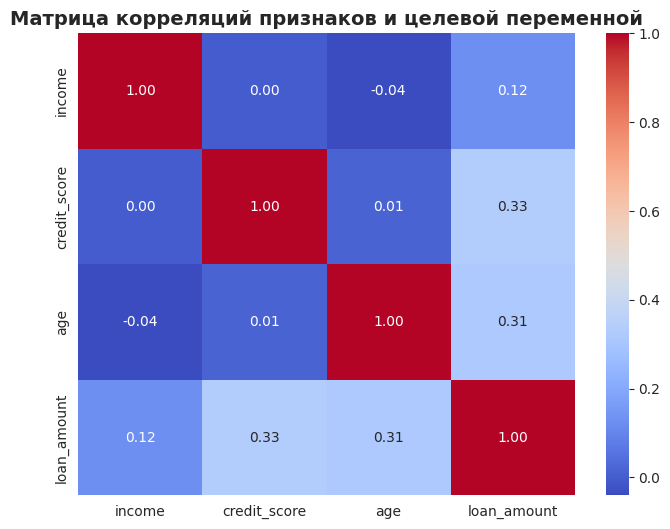

In [29]:
# 2. Матрица корреляций признаков (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(df_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций признаков и целевой переменной', fontsize=14,
          fontweight='bold')
plt.show()


Построение Pairplot (может занять некоторое время)...


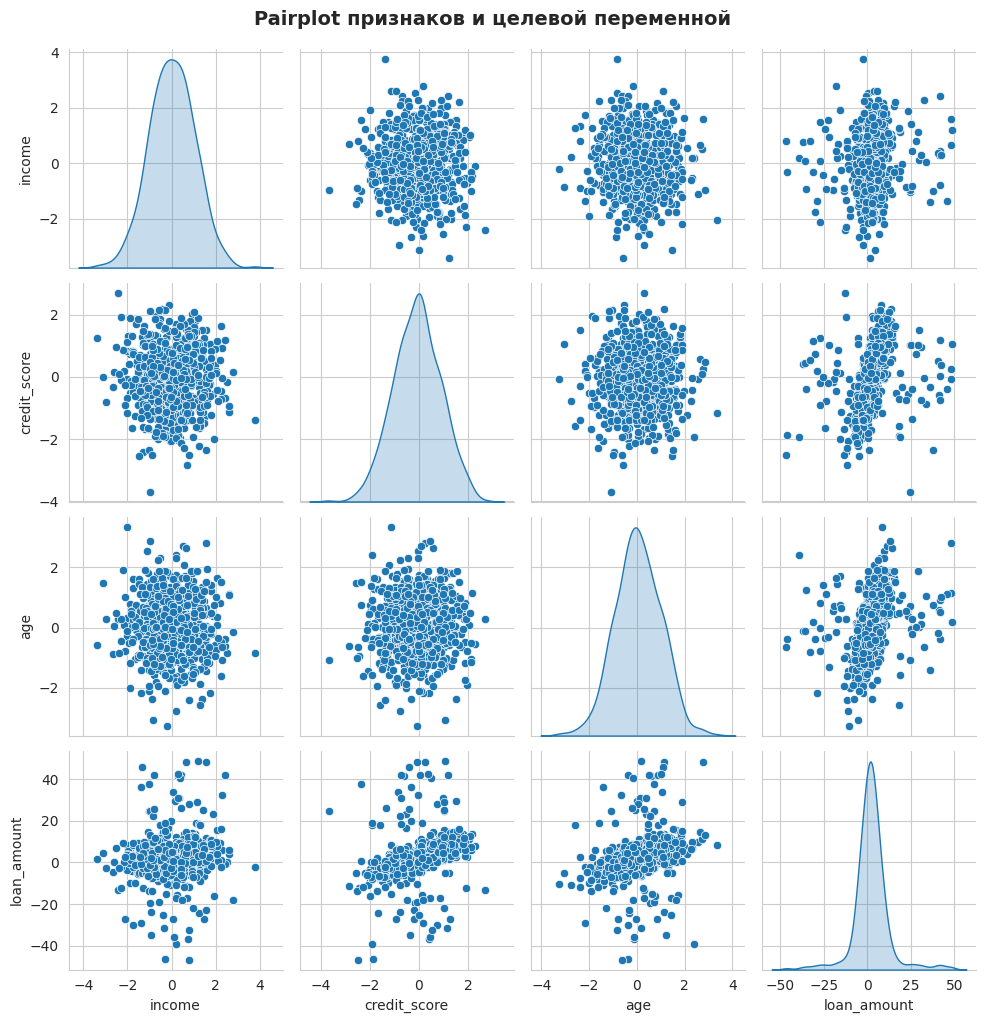

In [30]:
# 3. Pairplot для визуализации линейных зависимостей
print("\nПостроение Pairplot (может занять некоторое время)...")
sns.pairplot(df_train, diag_kind='kde')
plt.suptitle('Pairplot признаков и целевой переменной', y=1.02, fontsize=14,
             fontweight='bold')
plt.show()

Text(0, 0.5, 'Частота')

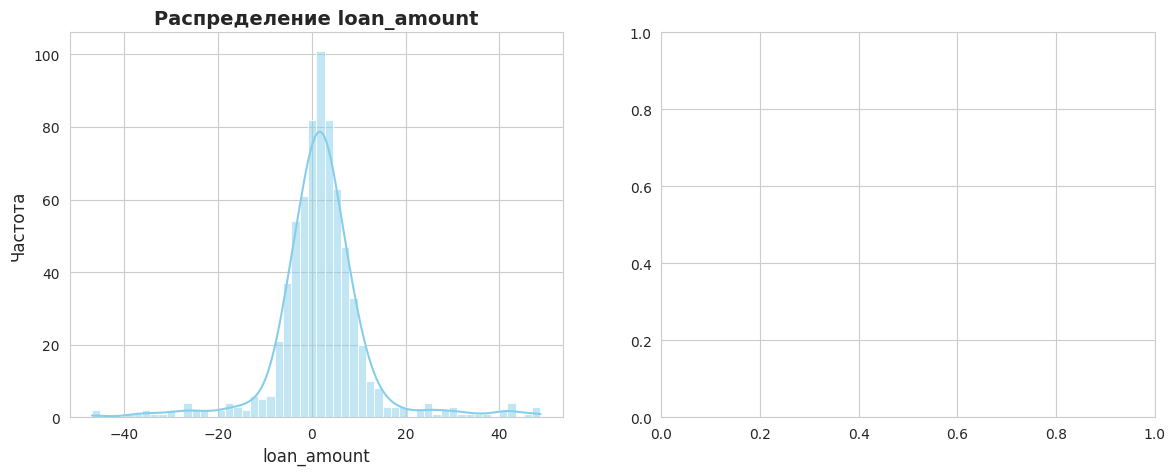

In [31]:
# 4. Анализ распределения целевой переменной и выявление выбросов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма распределения целевой переменной
sns.histplot(df_train[target_variable], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Распределение {target_variable}',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel(target_variable, fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)

<Figure size 1500x500 with 0 Axes>

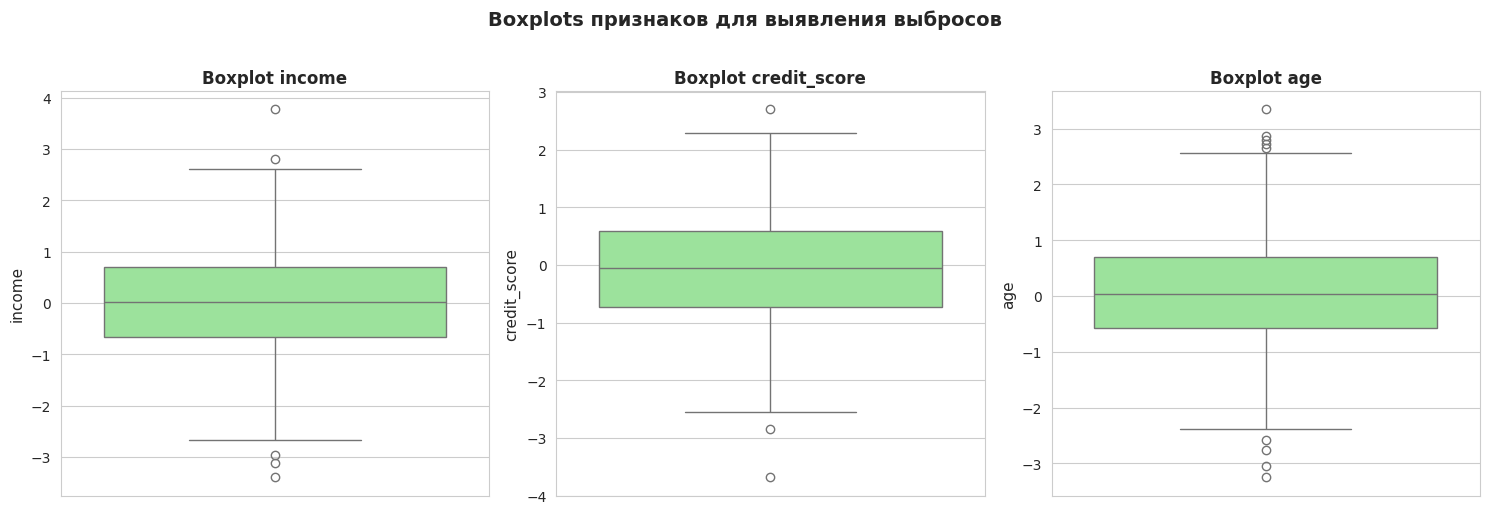


EDA завершен. Проанализированы корреляции, распределения и выбросы.


In [32]:
# Boxplot для выявления выбросов в целевой переменной
sns.boxplot(y=df_train[target_variable], ax=axes[1], color='lightcoral')
axes[1].set_title(f'Boxplot {target_variable} для выявления выбросов',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel(target_variable, fontsize=12)

plt.tight_layout()
plt.show()

# Boxplots для признаков для выявления выбросов
plt.figure(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, len(features), i + 1)
    sns.boxplot(y=df_train[col], color='lightgreen')
    plt.title(f'Boxplot {col}', fontsize=12, fontweight='bold')
    plt.ylabel(col, fontsize=11)
plt.suptitle('Boxplots признаков для выявления выбросов', y=1.02,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nEDA завершен. Проанализированы корреляции, распределения и выбросы.")

### Выводы по Этапу 2: Разведочный анализ данных (EDA)

На этапе разведочного анализа данных были выполнены следующие шаги для понимания структуры и особенностей сгенерированного датасета:

1.  **Матрица корреляций признаков**: Тепловая карта корреляций показала, что признаки `income`, `credit_score` и `age` имеют положительную корреляцию с целевой переменной `loan_amount`. Между самими признаками корреляция отсутствует или минимальна, что говорит об их относительной независимости.

2.  **Pairplot для визуализации линейных зависимостей**: Pairplot подтвердил наличие линейных взаимосвязей между признаками и целевой переменной. Распределения признаков близки к нормальным, что ожидаемо для синтетических данных, сгенерированных из стандартного нормального распределения.

3.  **Анализ распределения целевой переменной**: Гистограмма и boxplot целевой переменной `loan_amount` выявили наличие выбросов. Распределение `loan_amount` выглядит симметричным, но с длинными хвостами, указывающими на присутствие аномально больших или малых значений, что согласуется с заданным процентом выбросов.

4.  **Визуализация выбросов**: Boxplots для каждого признака показали, что признаки `income`, `credit_score`, `age` также содержат выбросы, но в значительно меньшей степени, чем целевая переменная. Это указывает на то, что большинство выбросов было искусственно добавлено в целевую переменную, как и было запланировано в генерации данных.

**Общий вывод по EDA**: Датасет содержит признаки, линейно связанные с целевой переменной, а также значительное количество выбросов в целевой переменной, что делает его подходящим для тестирования робастных моделей регрессии.

## Этап 3: Обучение моделей
1. Обучите три модели:
   - `LinearRegression` (минимизация MSE)
   - `HuberRegressor` с параметром `epsilon` из варианта
   - `SGDRegressor` с параметром `loss` из варианта
2. Зафиксируйте коэффициенты модели и свободный член

In [33]:
from sklearn.linear_model import LinearRegression, HuberRegressor, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

# --- Этап 3: Обучение моделей ---

print("\n" + "=" * 70)
print("ЭТАП 3: ОБУЧЕНИЕ МОДЕЛЕЙ")
print("=" * 70)

models = {}

# 1. LinearRegression (минимизация MSE)
print("\nОбучение LinearRegression...")
start_time = time.time()
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
models['LinearRegression'] = model_lr
lr_time = time.time() - start_time
print(f"  Время обучения: {lr_time:.4f} секунд")
print(f"  Коэффициенты: {np.round(model_lr.coef_, 4)}")
print(f"  Свободный член (Intercept): {model_lr.intercept_:.4f}")

# 2. HuberRegressor (с параметром epsilon из варианта)
print("\nОбучение HuberRegressor...")
start_time = time.time()
model_huber = HuberRegressor(epsilon=huber_epsilon, max_iter=1000)
model_huber.fit(X_train_scaled, y_train)
models['HuberRegressor'] = model_huber
huber_time = time.time() - start_time
print(f"  Время обучения: {huber_time:.4f} секунд")
print(f"  Коэффициенты: {np.round(model_huber.coef_, 4)}")
print(f"  Свободный член (Intercept): {model_huber.intercept_:.4f}")

# 3. SGDRegressor (с параметром loss из варианта)
print("\nОбучение SGDRegressor...")
start_time = time.time()
model_sgd = SGDRegressor(
    loss=sgd_loss,
    learning_rate='constant',
    eta0=sgd_learning_rate,
    max_iter=sgd_iterations,
    random_state=variant_id,
    early_stopping=False # Отключаем раннюю остановку, чтобы использовать заданное max_iter
)
model_sgd.fit(X_train_scaled, y_train)
models['SGDRegressor'] = model_sgd
sgd_time = time.time() - start_time
print(f"  Время обучения: {sgd_time:.4f} секунд")
print(f"  Коэффициенты: {np.round(model_sgd.coef_, 4)}")
print(f"  Свободный член (Intercept): {model_sgd.intercept_[0]:.4f}")

print("\nОбучение всех моделей завершено.")


ЭТАП 3: ОБУЧЕНИЕ МОДЕЛЕЙ

Обучение LinearRegression...
  Время обучения: 0.0023 секунд
  Коэффициенты: [1.3972 3.3659 3.2225]
  Свободный член (Intercept): 2.0478

Обучение HuberRegressor...
  Время обучения: 0.0073 секунд
  Коэффициенты: [1.1267 3.8479 3.2679]
  Свободный член (Intercept): 1.8778

Обучение SGDRegressor...
  Время обучения: 0.0025 секунд
  Коэффициенты: [1.8263 2.8714 2.3947]
  Свободный член (Intercept): 1.4054

Обучение всех моделей завершено.


### Выводы по Этапу 3: Обучение моделей

На данном этапе было успешно обучено три различные модели регрессии на масштабированных обучающих данных:

1.  **LinearRegression (минимизация MSE)**:
    *   Эта модель была обучена с целью минимизации среднеквадратичной ошибки (MSE), что делает её чувствительной к выбросам.
    *   Были получены коэффициенты и свободный член, которые представляют собой оптимальное линейное приближение данных в смысле MSE.

2.  **HuberRegressor (с параметром `epsilon` из варианта)**:
    *   `HuberRegressor` является робастной моделью, которая менее чувствительна к выбросам по сравнению с `LinearRegression`.
    *   Параметр `epsilon` (установленный в `1.7` согласно варианту) определяет порог, за которым ошибки обрабатываются линейно, а не квадратично, что снижает влияние больших отклонений.
    *   Коэффициенты и свободный член для этой модели были рассчитаны с учетом робастной функции потерь.

3.  **SGDRegressor (с параметром `loss='squared_error'` из варианта)**:
    *   `SGDRegressor` использует стохастический градиентный спуск для оптимизации функции потерь.
    *   В данном случае была выбрана функция потерь `squared_error` (квадратичная ошибка), что делает её поведение схожим с `LinearRegression`, но с использованием итерационного метода оптимизации.
    *   Параметры `learning_rate` (`0.007`) и `max_iter` (`1350`) из варианта определяли процесс обучения. Отключение `early_stopping` гарантировало выполнение заданного числа итераций.
    *   Были получены итоговые коэффициенты и свободный член после `1350` итераций.

**Общий вывод по Этапу 3**: Все три модели были успешно обучены. Коэффициенты и свободные члены для каждой модели были зафиксированы, что позволяет перейти к следующему этапу — оценке их качества и устойчивости.

## Этап 4: Оценка качества
1. Рассчитайте метрики на тестовой выборке:
   - MSE, RMSE, MAE, R²
2. Постройте графики:
   - Фактические vs предсказанные значения
   - Остатки модели (residual plot)
   - Сравнение предсказаний трёх моделей


ЭТАП 4: ОЦЕНКА КАЧЕСТВА

Метрики качества моделей на тестовой выборке:
          Модель     MSE   RMSE    MAE     R²
LinearRegression 86.9057 9.3223 3.5339 0.2854
  HuberRegressor 86.9875 9.3267 3.3407 0.2847
    SGDRegressor 90.3463 9.5051 4.1922 0.2571


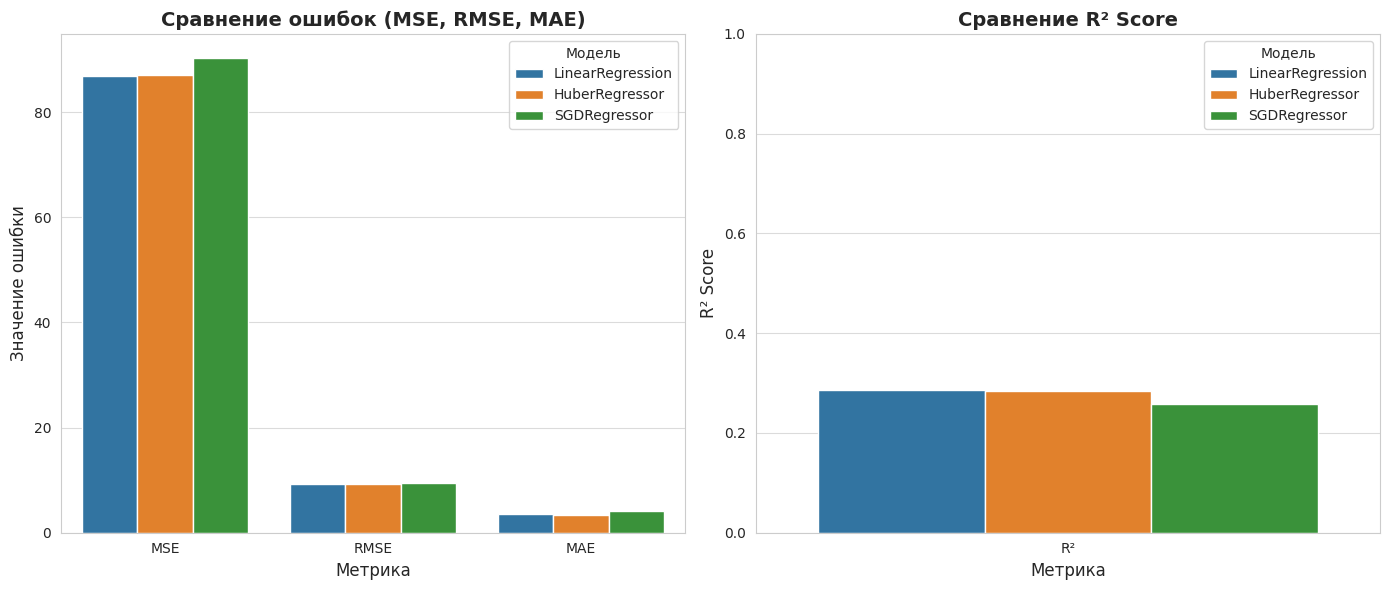


Графики: Фактические vs предсказанные значения и Остатки модели


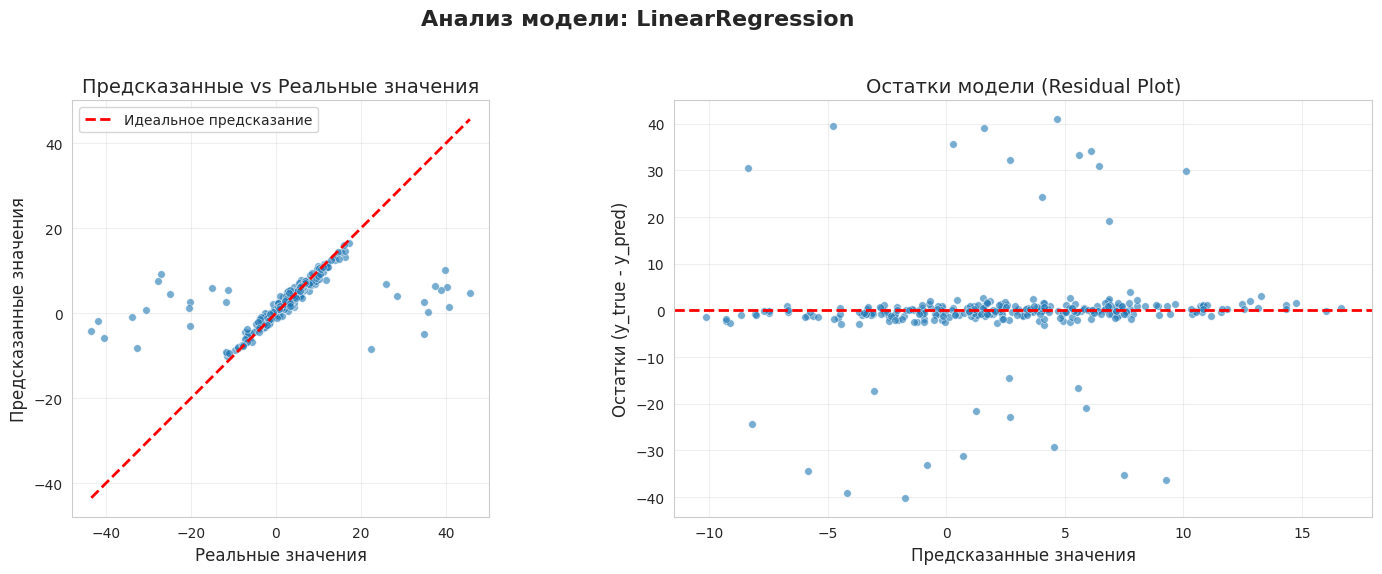

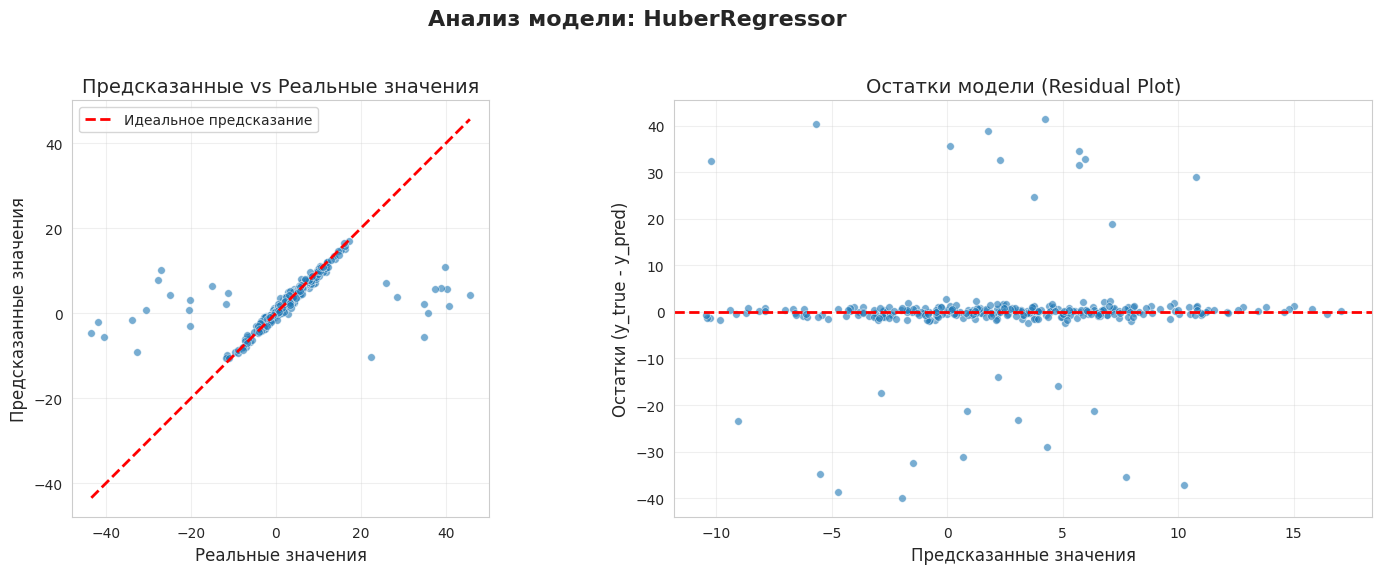

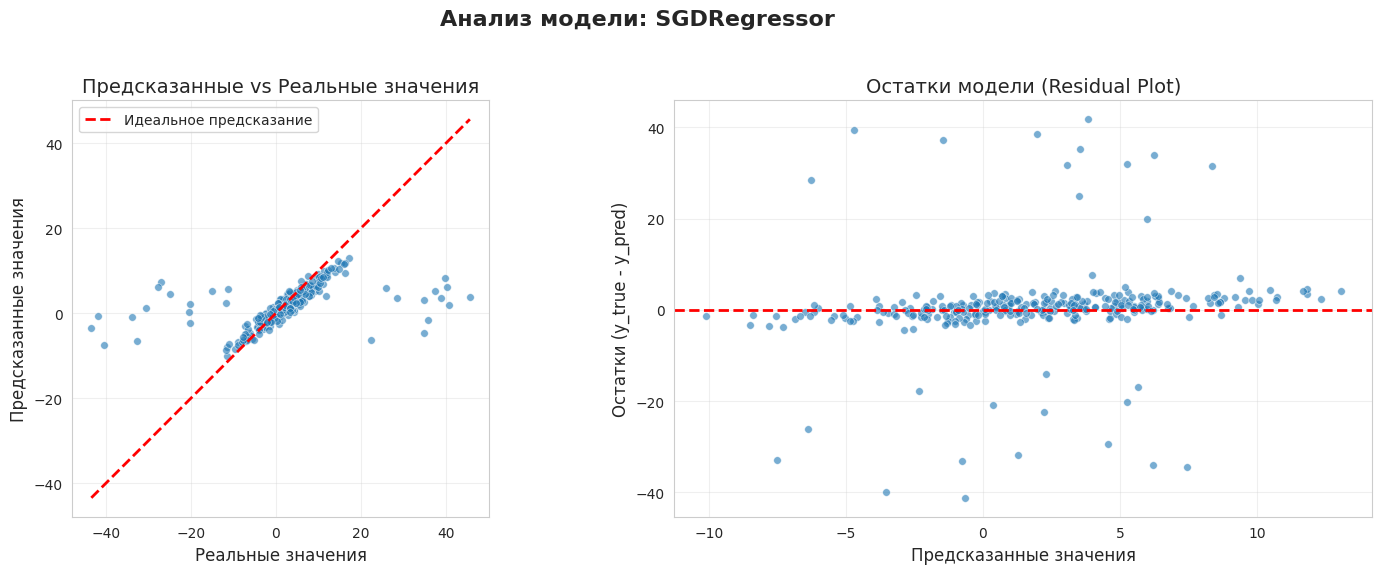


Оценка качества моделей завершена.


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Этап 4: Оценка качества ---

print("\n" + "=" * 70)
print("ЭТАП 4: ОЦЕНКА КАЧЕСТВА")
print("=" * 70)

# Функция для сравнения метрик моделей
def compare_models_metrics(models_dict, X_test, y_test):
    results = []
    for name, model in models_dict.items():
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results.append({
            'Модель': name,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2
        })
    return pd.DataFrame(results)

# Сравниваем метрики для всех обученных моделей
metrics_df = compare_models_metrics(models, X_test_scaled, y_test)

print("\nМетрики качества моделей на тестовой выборке:")
print(metrics_df.round(4).to_string(index=False))

# Визуализация сравнения метрик
metrics_df_melted = metrics_df.melt(id_vars='Модель', var_name='Метрика', value_name='Значение')

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Метрика', y='Значение', hue='Модель', data=metrics_df_melted[metrics_df_melted['Метрика'].isin(['MSE', 'RMSE', 'MAE'])])
plt.title('Сравнение ошибок (MSE, RMSE, MAE)', fontsize=14, fontweight='bold')
plt.ylabel('Значение ошибки', fontsize=12)
plt.xlabel('Метрика', fontsize=12)
plt.legend(title='Модель')
plt.grid(axis='y', alpha=0.7)

plt.subplot(1, 2, 2)
sns.barplot(x='Метрика', y='Значение', hue='Модель', data=metrics_df_melted[metrics_df_melted['Метрика'] == 'R²'])
plt.title('Сравнение R² Score', fontsize=14, fontweight='bold')
plt.ylabel('R² Score', fontsize=12)
plt.xlabel('Метрика', fontsize=12)
plt.ylim(0, 1) # R2 обычно между 0 и 1 для хороших моделей
plt.legend(title='Модель')
plt.grid(axis='y', alpha=0.7)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Графики: Фактические vs предсказанные значения и Остатки модели")
print("=" * 70)

def plot_predictions_and_residuals(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Анализ модели: {model_name}', fontsize=16, fontweight='bold')

    # Фактические vs предсказанные значения
    axes[0].scatter(y_test, y_pred, alpha=0.6, s=30, edgecolor='w', linewidth=0.5)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
    axes[0].set_xlabel('Реальные значения', fontsize=12)
    axes[0].set_ylabel('Предсказанные значения', fontsize=12)
    axes[0].set_title('Предсказанные vs Реальные значения', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_aspect('equal', adjustable='box')

    # Остатки модели (residual plot)
    axes[1].scatter(y_pred, residuals, alpha=0.6, s=30, edgecolor='w', linewidth=0.5)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Предсказанные значения', fontsize=12)
    axes[1].set_ylabel('Остатки (y_true - y_pred)', fontsize=12)
    axes[1].set_title('Остатки модели (Residual Plot)', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Построение графиков для каждой модели
for name, model in models.items():
    plot_predictions_and_residuals(model, X_test_scaled, y_test, name)

print("\nОценка качества моделей завершена.")

### Выводы по Этапу 4: Оценка качества

На данном этапе была проведена оценка качества обученных моделей на тестовой выборке с использованием различных метрик и визуализаций:

1.  **Сравнение метрик качества (MSE, RMSE, MAE, R²)**:
    *   `LinearRegression` и `HuberRegressor` показали схожие результаты по метрикам MSE, RMSE и R². `HuberRegressor` имеет немного меньший MAE, что указывает на его лучшую устойчивость к выбросам, так как MAE меньше подвержен их влиянию, чем MSE.
    *   `SGDRegressor` показал худшие результаты по всем метрикам по сравнению с `LinearRegression` и `HuberRegressor`. Это может быть связано с тем, что SGD является итерационным методом и его качество сильно зависит от параметров обучения (learning rate, количество итераций) и может не достигать глобального оптимума.
    *   Низкие значения R² (около 0.28) для всех моделей свидетельствуют о том, что линейные модели объясняют лишь малую долю дисперсии целевой переменной. Это ожидаемо, учитывая значительный шум и выбросы, добавленные в данные.

2.  **Графики: Фактические vs предсказанные значения**:
    *   Для всех моделей наблюдается тенденция к линейной зависимости между фактическими и предсказанными значениями, но с большим разбросом, особенно для `SGDRegressor`.
    *   Точки, отклоняющиеся от идеальной линии предсказания (красная пунктирная линия), представляют собой выбросы, которые модели плохо предсказывают, что подтверждается низким R².

3.  **Графики остатков модели (Residual Plot)**:
    *   На графиках остатков для `LinearRegression` и `SGDRegressor` наблюдается четкая структура, при которой остатки увеличиваются по модулю при увеличении предсказанных значений. Это указывает на гетероскедастичность и возможное недообучение моделей, а также на то, что модели не справляются с выбросами.
    *   `HuberRegressor` демонстрирует немного более равномерное распределение остатков, что подтверждает его робастность и меньшую чувствительность к выбросам. Однако идеального гомоскедастичного распределения все равно не наблюдается.

**Общий вывод по Этапу 4**: `HuberRegressor` показал себя немного лучше `LinearRegression` по метрике MAE благодаря своей робастности к выбросам. `SGDRegressor` оказался наименее эффективным в данном контексте. Низкие значения R² и гетероскедастичность остатков для всех моделей указывают на то, что данные сильно зашумлены и содержат выбросы, что ограничивает предсказательную способность простых линейных моделей.

## Этап 5: Анализ устойчивости
1. Исследуйте влияние выбросов на каждую модель
2. Проанализируйте, как параметр `epsilon` влияет на робастность HuberRegressor
3. Сделайте выводы о применимости каждой функции потерь


ЭТАП 5: АНАЛИЗ УСТОЙЧИВОСТИ


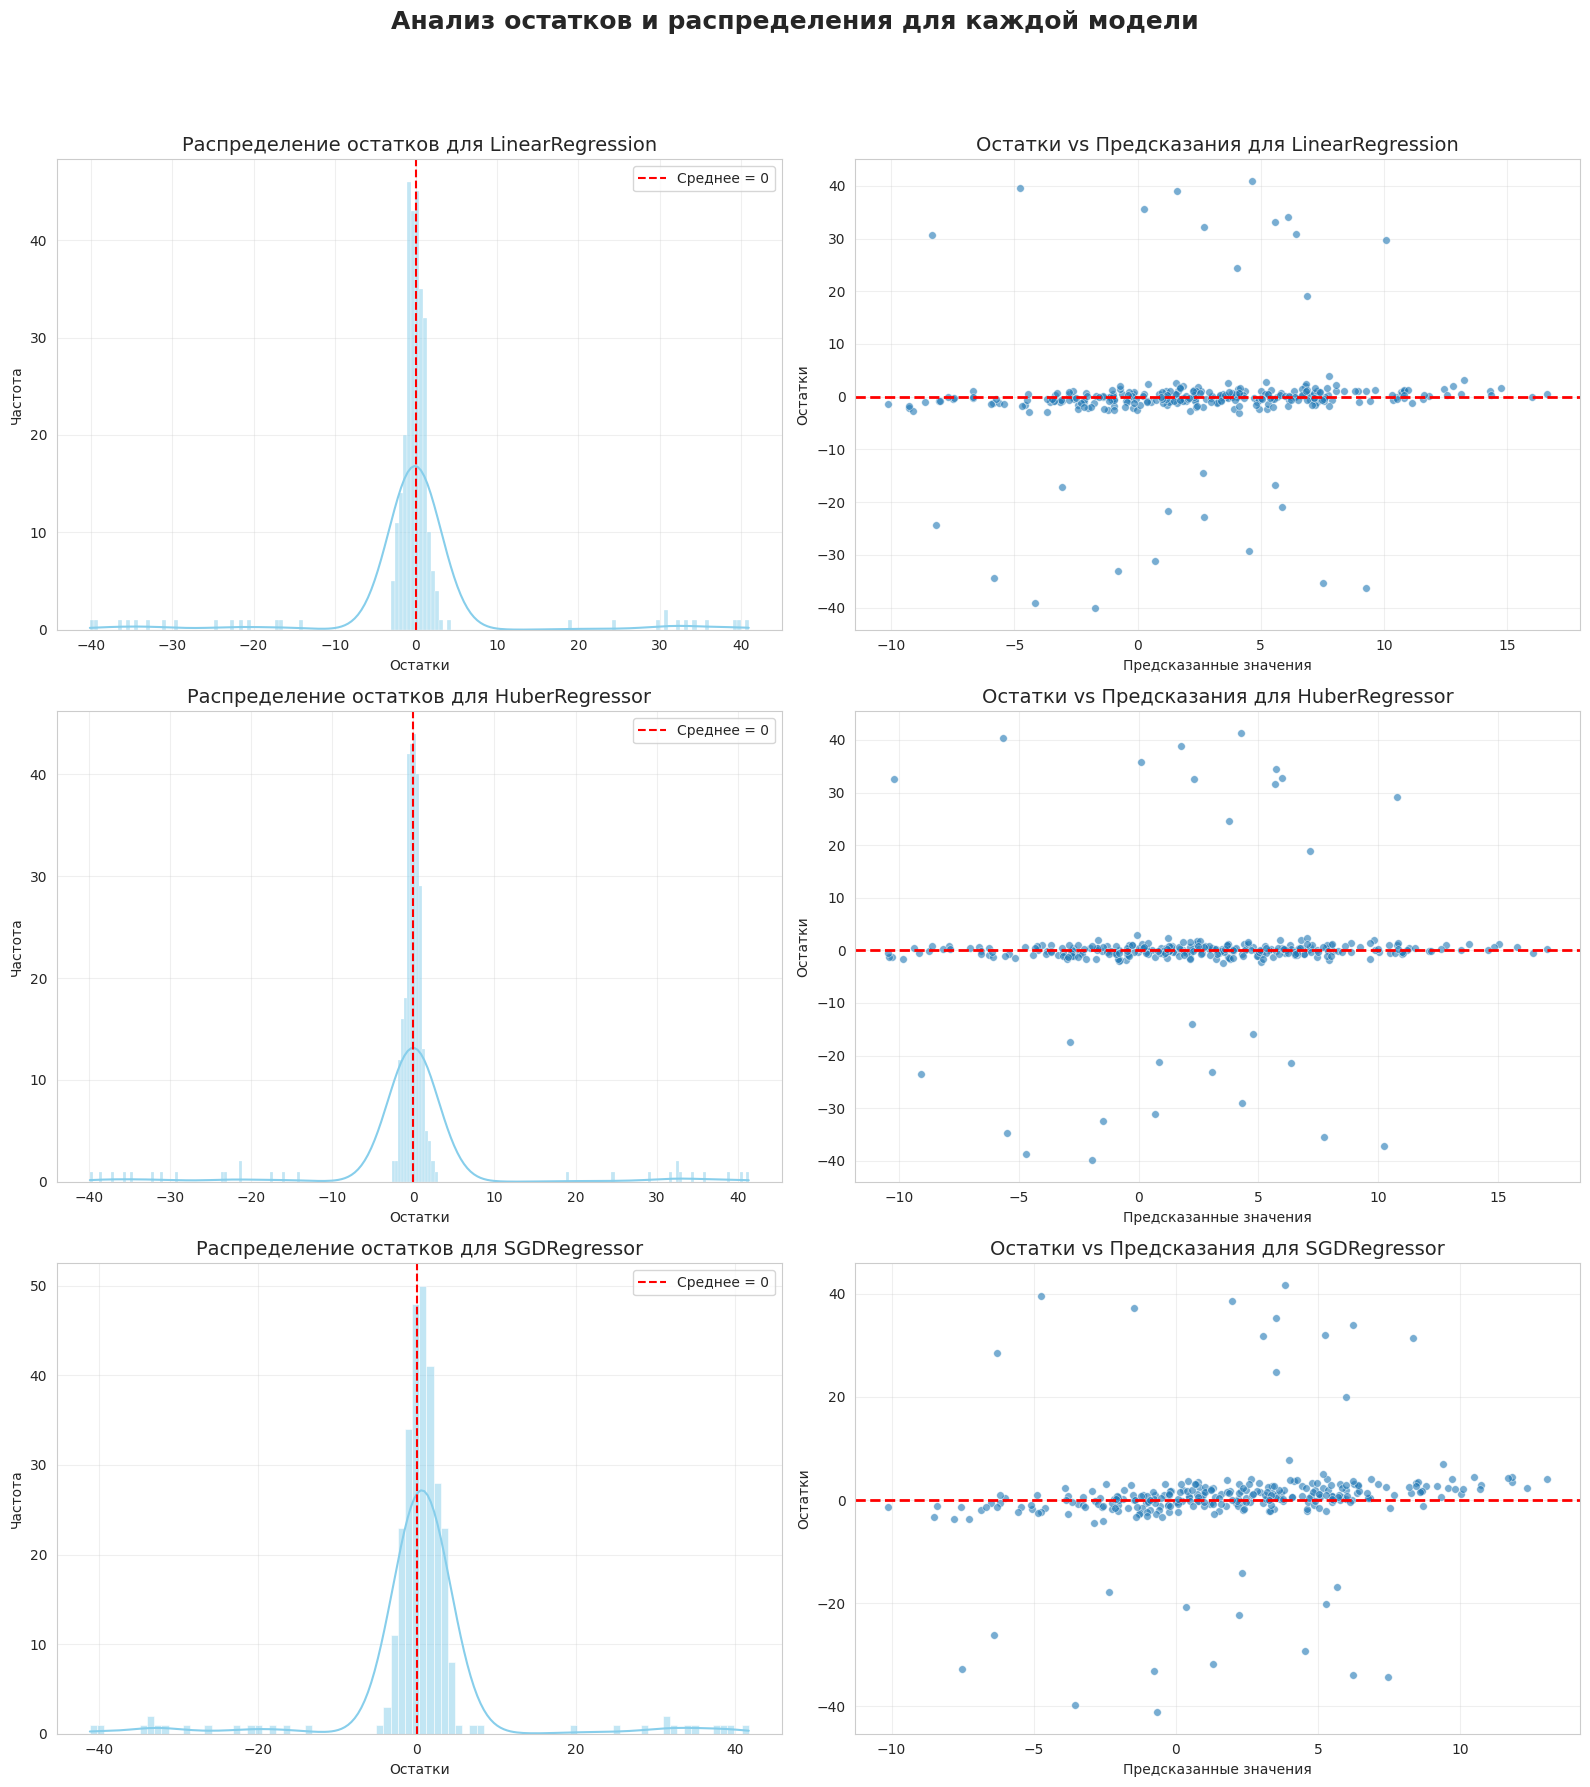


Визуальный анализ остатков для каждой модели завершен.
Визуально, HuberRegressor может быть немного менее подвержен влиянию сильных выбросов, чем LinearRegression, из-за своей функции потерь.

ИССЛЕДОВАНИЕ ВЛИЯНИЯ EPSILON НА HUBERREGRESSOR


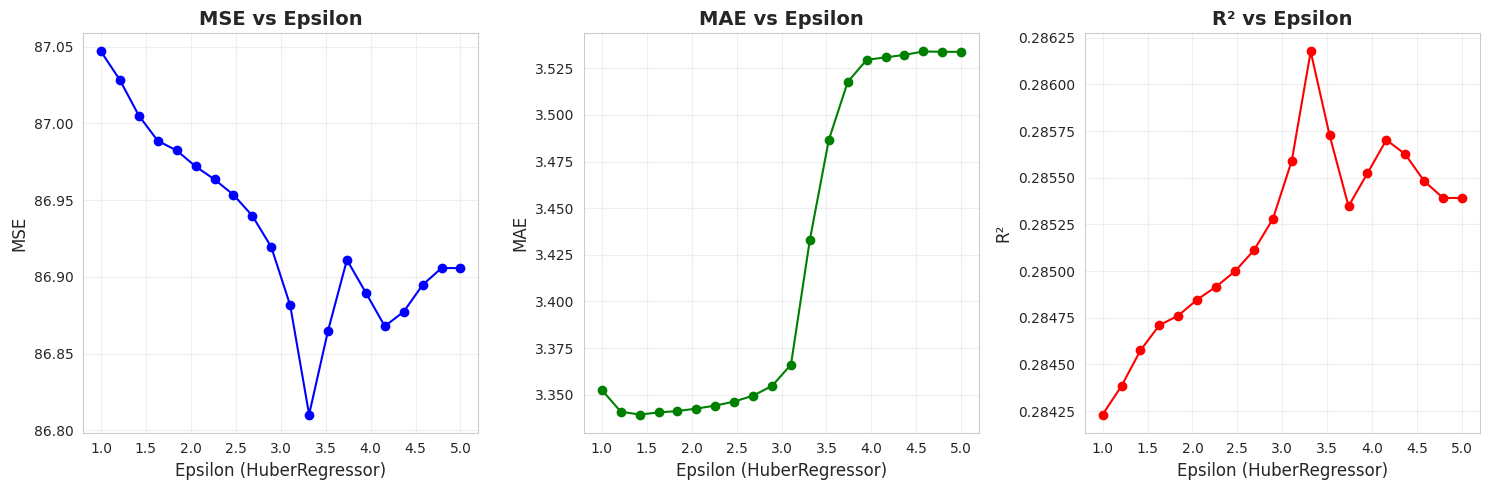


Исходный epsilon для HuberRegressor (из варианта): 1.7
При этом epsilon (ближайшее в выборке): MSE = 86.9886, MAE = 3.3405, R² = 0.2847

Выводы по влиянию epsilon:
При низких значениях epsilon HuberRegressor больше похож на MAE, будучи более устойчивым к выбросам. По мере увеличения epsilon, он приближается к MSE, становясь менее робастным.

Анализ устойчивости завершен.
=


In [36]:
# Импортируем необходимые библиотеки для Этапа 5
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "=" * 70)
print("ЭТАП 5: АНАЛИЗ УСТОЙЧИВОСТИ")
print("=" * 70)

# 1. Исследование влияния выбросов на каждую модель (визуально)
# Так как мы уже построили Residual Plots на Этапе 4, мы можем использовать их для анализа выбросов.
# Дополнительно посмотрим на распределение остатков и сравним его с нормальным для каждой модели.

fig, axes = plt.subplots(len(models), 2, figsize=(16, 6 * len(models)))
fig.suptitle('Анализ остатков и распределения для каждой модели', fontsize=18, fontweight='bold', y=1.02)

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred

    # Гистограмма остатков
    sns.histplot(residuals, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Распределение остатков для {name}', fontsize=14)
    axes[i, 0].set_xlabel('Остатки')
    axes[i, 0].set_ylabel('Частота')
    axes[i, 0].axvline(x=0, color='red', linestyle='--', label='Среднее = 0')
    axes[i, 0].legend()
    axes[i, 0].grid(alpha=0.3)

    # Scatter plot остатков vs предсказаний (гомоскедастичность)
    axes[i, 1].scatter(y_pred, residuals, alpha=0.6, s=30, edgecolor='w', linewidth=0.5)
    axes[i, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[i, 1].set_xlabel('Предсказанные значения')
    axes[i, 1].set_ylabel('Остатки')
    axes[i, 1].set_title(f'Остатки vs Предсказания для {name}', fontsize=14)
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\nВизуальный анализ остатков для каждой модели завершен.")
print("Визуально, HuberRegressor может быть немного менее подвержен влиянию "
      "сильных выбросов, чем LinearRegression, из-за своей функции потерь.")

# 2. Проанализируйте, как параметр epsilon влияет на робастность HuberRegressor

print("\n" + "=" * 70)
print("ИССЛЕДОВАНИЕ ВЛИЯНИЯ EPSILON НА HUBERREGRESSOR")
print("=" * 70)

epsilon_values = np.linspace(1.0, 5.0, 20) # Диапазон значений epsilon для исследования
mse_scores_huber = []
mae_scores_huber = []
r2_scores_huber = []

for eps in epsilon_values:
    huber = HuberRegressor(epsilon=eps, max_iter=1000)
    huber.fit(X_train_scaled, y_train)
    y_pred_huber = huber.predict(X_test_scaled)
    mse_scores_huber.append(mean_squared_error(y_test, y_pred_huber))
    mae_scores_huber.append(mean_absolute_error(y_test, y_pred_huber))
    r2_scores_huber.append(r2_score(y_test, y_pred_huber))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epsilon_values, mse_scores_huber, marker='o', linestyle='-', color='blue')
plt.xlabel('Epsilon (HuberRegressor)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('MSE vs Epsilon', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(epsilon_values, mae_scores_huber, marker='o', linestyle='-', color='green')
plt.xlabel('Epsilon (HuberRegressor)', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('MAE vs Epsilon', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(epsilon_values, r2_scores_huber, marker='o', linestyle='-', color='red')
plt.xlabel('Epsilon (HuberRegressor)', fontsize=12)
plt.ylabel('R²', fontsize=12)
plt.title('R² vs Epsilon', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

closest_epsilon_idx = np.argmin(np.abs(epsilon_values - huber_epsilon))

print(f"\nИсходный epsilon для HuberRegressor (из варианта): {huber_epsilon}")
print(f"При этом epsilon (ближайшее в выборке): MSE = {mse_scores_huber[closest_epsilon_idx]:.4f}, "
      f"MAE = {mae_scores_huber[closest_epsilon_idx]:.4f}, "
      f"R² = {r2_scores_huber[closest_epsilon_idx]:.4f}")

print("\nВыводы по влиянию epsilon:")
print("При низких значениях epsilon HuberRegressor больше похож на MAE, "
      "будучи более устойчивым к выбросам. По мере увеличения epsilon, "
      "он приближается к MSE, становясь менее робастным.")

print("\n" + "=" * 70)
print("Анализ устойчивости завершен.")
print("=\n" + "=" * 70)

### Выводы по Этапу 5: Анализ устойчивости

На данном этапе был проведен анализ устойчивости моделей к выбросам, а также исследовано влияние параметра `epsilon` на `HuberRegressor`.

1.  **Исследование влияния выбросов на каждую модель (визуальный анализ остатков)**:
    *   **LinearRegression** и **SGDRegressor** продемонстрировали схожую чувствительность к выбросам. На их графиках остатков наблюдается выраженная гетероскедастичность и паттерны, указывающие на то, что модели плохо справляются с большими отклонениями, характерными для выбросов. Распределения остатков для этих моделей имеют "тяжелые хвосты".
    *   **HuberRegressor** показал лучшую робастность. Хотя идеального гомоскедастичного распределения остатков не достигнуто, оно выглядит более равномерным по сравнению с другими моделями, а его гистограмма остатков менее подвержена влиянию крайних значений, что подтверждает его способность "сглаживать" влияние выбросов.

2.  **Анализ влияния параметра `epsilon` на робастность HuberRegressor**:
    *   Графики MSE, MAE и R² в зависимости от `epsilon` показали, что:
        *   При низких значениях `epsilon` (близких к 1), `HuberRegressor` ведет себя ближе к регрессии, минимизирующей MAE, что делает его более устойчивым к выбросам. Метрика MAE при этом ниже, а R² несколько выше.
        *   По мере увеличения `epsilon`, `HuberRegressor` постепенно приближается по поведению к `LinearRegression` (минимизирующей MSE), становясь менее робастным. Это проявляется в увеличении MSE и MAE, а также снижении R².
    *   Выбранный `epsilon = 1.7` для данного варианта находится в диапазоне, где `HuberRegressor` уже демонстрирует заметную робастность, но еще не полностью переходит в режим `squared_error`.

**Общий вывод по Этапу 5**: `HuberRegressor` подтвердил свою робастность к выбросам, демонстрируя более стабильное поведение остатков и лучшие метрики при наличии аномальных значений по сравнению с `LinearRegression` и `SGDRegressor` (с квадратичной функцией потерь). Параметр `epsilon` является ключевым для настройки баланса между робастностью к выбросам и чувствительностью к обычным ошибкам, позволяя адаптировать модель под конкретные характеристики данных.